# Parte 1: Análise Exploratória

## Panorama dos Chamados

**Objetivo**: Explorar o corpus de 5.000 chamados da Central 1746 para entender as características e padrões dos dados. A análise foca no **problema de classificação**, de forma a encontrar possíveis insights que possam ajudar durante o processo de modelagem do problema.

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures')

In [2]:
cat_map = {
    'iluminacao_publica': 'Iluminação Pública',
    'buraco_via': 'Buraco em Via',
    'coleta_lixo': 'Coleta de Lixo',
    'esgoto_vazamento': 'Vazamento de Esgoto',
    'poda_arvore': 'Poda de Árvore',
    'estacionamento_irregular': 'Estacionamento Irregular',
    'barulho_perturbacao': 'Barulho / Perturbação',
    'sinalizacao': 'Sinalização'
}

cat_palette = {
    'iluminacao_publica': '#f4a261',
    'buraco_via': '#e76f51',
    'coleta_lixo': '#2a9d8f',
    'esgoto_vazamento': '#264653',
    'poda_arvore': '#8ab17d',
    'estacionamento_irregular': '#6b4c3b',
    'barulho_perturbacao': '#e9c46a',
    'sinalizacao': '#7b9ebf'
}

## Análise Inicial dos Dados

In [3]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')
df.head()

,id_chamado,data_abertura,bairro,canal,texto,categoria_real,pred_modelo_a,conf_modelo_a,pred_modelo_b,conf_modelo_b
0,2026003525,2026-01-16,Botafogo,app_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.939,barulho_perturbacao,0.883
1,2026001235,2026-06-20,Ilha do Governador,telefone_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.927,barulho_perturbacao,0.975
2,2026003000,2026-02-17,Campo Grande,portal_web,Solicito reparo urgente na iluminação pública ...,iluminacao_publica,iluminacao_publica,0.947,iluminacao_publica,0.829
3,2026002594,2026-01-15,Tijuca,app_1746,A luminária do poste da Rua Dias da Cruz esqui...,iluminacao_publica,coleta_lixo,0.964,iluminacao_publica,0.882
4,2026003670,2026-01-07,Penha,app_1746,Solicito remoção de entulho e lixo acumulado n...,coleta_lixo,buraco_via,0.924,coleta_lixo,0.765


In [4]:
print(f'Dimensão: {df.shape}\n')
print(f'Tipo:\n{df.dtypes}\n')
print(f'Quantidade de campos nulos:\n{df.isna().sum()}\n')

ids_duplicados = df['id_chamado'].duplicated().sum()
print(f'IDs duplicados: {ids_duplicados}')

Dimensão: (5000, 10)

Tipo:
id_chamado          int64
data_abertura      object
bairro             object
canal              object
texto              object
categoria_real     object
pred_modelo_a      object
conf_modelo_a     float64
pred_modelo_b      object
conf_modelo_b     float64
dtype: object

Quantidade de campos nulos:
id_chamado        0
data_abertura     0
bairro            0
canal             0
texto             0
categoria_real    0
pred_modelo_a     0
conf_modelo_a     0
pred_modelo_b     0
conf_modelo_b     0
dtype: int64

IDs duplicados: 0


In [5]:
resumo_base = {
    'total_chamados': len(df),
    'periodo_inicio': df['data_abertura'].min(),
    'periodo_fim': df['data_abertura'].max(),
    'n_categorias': df['categoria_real'].nunique(),
    'n_bairros': df['bairro'].nunique(),
    'n_canais': df['canal'].nunique()
}

resumo_base

{'total_chamados': 5000,
 'periodo_inicio': '2026-01-01',
 'periodo_fim': '2026-06-30',
 'n_categorias': 8,
 'n_bairros': 15,
 'n_canais': 3}

## Análise Exploratória

### 1. Distribuição das Categorias

In [6]:
cat_counts = df['categoria_real'].value_counts()
cat_props = df['categoria_real'].value_counts(normalize=True)

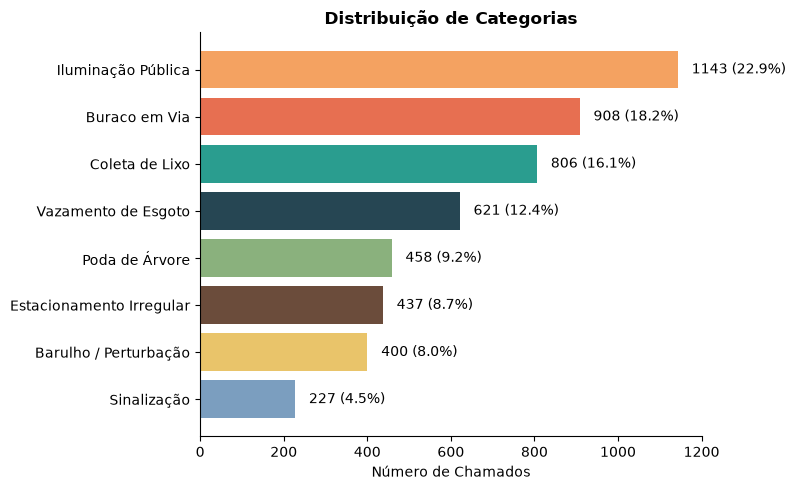

In [7]:
total = cat_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    [cat_map.get(c, c) for c in cat_counts.index],
    cat_counts.values,
    color=[cat_palette.get(c, '#888') for c in cat_counts.index]
)

labels = [
    f'{v} ({v/total:.1%})'
    for v in cat_counts.values
]

ax.bar_label(bars, labels=labels, padding=10)

ax.set_xlabel('Número de Chamados')
ax.set_title('Distribuição de Categorias', fontweight='bold')
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categoria_distribuicao.png', dpi=150)
plt.show()

A distribuição das categorias é desigual: **Iluminação Pública** concentra 1.143
chamados (22,9%), enquanto **Sinalização** tem apenas 227 (4,5%).

### 2. Características dos Textos

#### 2.1. Características Gerais 

In [8]:
df['texto_len'] = df['texto'].str.len()
df['texto_words'] = df['texto'].str.split().str.len()

print('Estatísticas gerais do texto:')
print(f'Comprimento (caracteres): média={df["texto_len"].mean():.1f}, mediana={df["texto_len"].median():.0f}, std={df["texto_len"].std():.1f}')
print(f'Palavras: média={df["texto_words"].mean():.1f}, mediana={df["texto_words"].median():.0f}, std={df["texto_words"].std():.1f}\n')

stats_text = df.groupby('categoria_real')['texto_len'].agg(['mean', 'median', 'std', 'min', 'max'])
stats_text.index = [cat_map.get(c, c) for c in stats_text.index]
stats_text.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Mín', 'Máx']
print('Estatísticas por categoria:')
print(stats_text.round(1).to_string())

duplicados = df['texto'].duplicated().sum()
pct_duplicados = duplicados / len(df) * 100

print(f'\nTextos duplicados: {duplicados} ({pct_duplicados:.1f}%)')

Estatísticas gerais do texto:
Comprimento (caracteres): média=128.2, mediana=156, std=57.1
Palavras: média=23.3, mediana=28, std=10.6

Estatísticas por categoria:
                          Média  Mediana  Desvio Padrão  Mín  Máx
Barulho / Perturbação     120.8    147.0           54.5   30  191
Buraco em Via             127.5    154.0           58.9   24  197
Coleta de Lixo            125.4    156.0           54.6   27  178
Vazamento de Esgoto       134.6    161.0           56.1   29  199
Estacionamento Irregular  127.0    150.0           53.7   29  192
Iluminação Pública        130.0    160.0           59.6   28  193
Poda de Árvore            131.4    160.0           59.2   27  199
Sinalização               124.3    153.0           54.0   31  180

Textos duplicados: 1409 (28.2%)


- Comprimento médio de **128 caracteres** (~23 palavras), com pouca variação
  entre categorias (médias de 121 a 135 caracteres), o que implica que o comprimento não é um fator predominante da distinção das categorias, porém vale ressaltar que o baixo número de palavras pode dificultar na diferenciação das categorias devido ao pouco contexto.
- **Interessante:** Na base tem 1.409 textos duplicados (28,2% da base), indicando descrições muito
  padronizadas/repetitivas, provavelmente pois a amostra foi gerado artificialmente, dado que em amostras reais é bem possível que esse valor seja bem reduzido.

In [9]:
textos_frequentes = (
    df['texto']
    .value_counts()
    .head(10)
    .reset_index()
)

textos_frequentes.columns = ['texto', 'frequencia']
textos_frequentes

,texto,frequencia
0,Obra com barulho fora de hora.,27
1,Asfalto cedeu há mais de dois meses.,16
2,"Rua escura há quase um mês, sem luz.",15
3,"Rua escura faz dois dias, sem luz.",15
4,Asfalto cedeu há 3 dias.,13
5,Coleta não passa há quase um mês.,12
6,"Rua escura desde ontem, sem luz.",12
7,Asfalto cedeu há quase um mês.,12
8,Coleta não passa faz dois dias.,11
9,Coleta não passa há mais de dois meses.,11


#### 2.2. Termos distintos por categoria

In [10]:
stopwords_pt = [
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das',
    'em', 'no', 'na', 'nos', 'nas',
    'para', 'por', 'com', 'sem',
    'que', 'e', 'ou', 'ao', 'à',
    'rua', 'avenida', 'av', 'local', 'já',
    'não'
]

In [11]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords_pt,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.3
)

X = vectorizer.fit_transform(df['texto'])
terms = np.array(vectorizer.get_feature_names_out())

In [12]:
categorias = sorted(df['categoria_real'].unique())

resultados = []

for categoria in categorias:
    idx_categoria = (df['categoria_real'] == categoria).to_numpy()
    tfidf_mean_categoria = X[idx_categoria].mean(axis=0).A1
    top_idx = tfidf_mean_categoria.argsort()[::-1][:10]
    
    for i in top_idx:
        resultados.append({
            'categoria': categoria,
            'termo': terms[i],
            'tfidf_mean_categoria': tfidf_mean_categoria[i],
        })

termos_distintivos = pd.DataFrame(resultados)

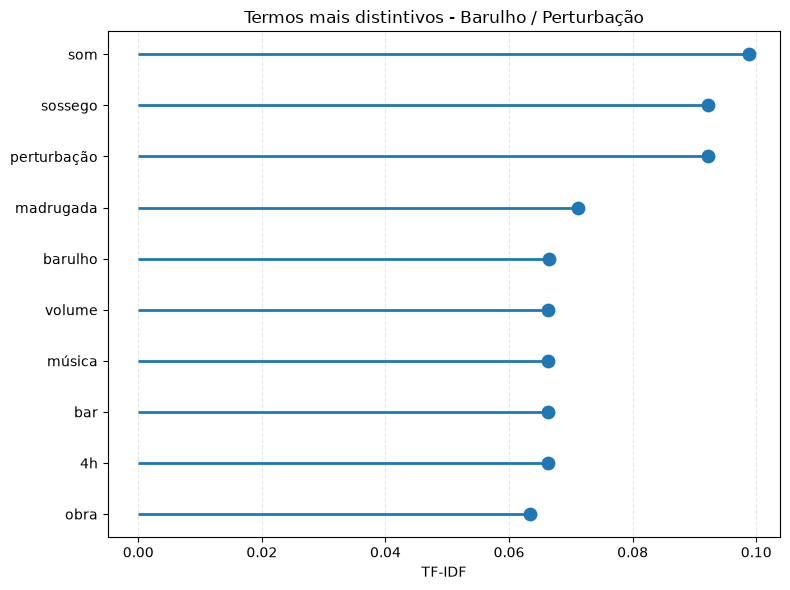

In [13]:
categoria = "barulho_perturbacao"

dados = (
    termos_distintivos
    .query("categoria == @categoria")
    .sort_values("tfidf_mean_categoria")
)

fig, ax = plt.subplots(figsize=(8,6))

ax.hlines(
    y=dados["termo"],
    xmin=0,
    xmax=dados["tfidf_mean_categoria"],
    linewidth=2
)

ax.scatter(
    dados["tfidf_mean_categoria"],
    dados["termo"],
    s=80,
    zorder=3
)

ax.set_xlabel("TF-IDF")
ax.set_ylabel("")
ax.set_title(f"Termos mais distintivos - {cat_map.get(categoria, categoria)}")

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
top_termos_por_categoria = (
    termos_distintivos
    .groupby('categoria')['termo']
    .apply(lambda x: ', '.join(x))
    .reset_index()
)

pd.set_option('display.max_colwidth', None)
display(top_termos_por_categoria)

,categoria,termo
0,barulho_perturbacao,"som, perturbação, sossego, madrugada, barulho, volume, 4h, bar, música, obra"
1,buraco_via,"buraco, asfalto, cedeu, pista, cratera, ônibus, via, risco, mais, dois"
2,coleta_lixo,"lixo, coleta, acumulado, entulho, passa, caçamba, descarte, irregular, remoção, transbordando"
3,esgoto_vazamento,"água, esgoto, vazamento, bueiro, transbordando, cheiro, pela, casas, asfalto, pista"
4,estacionamento_irregular,"vaga, deficiente, fila, dupla, abandonado, veículo, carros, motoristas, fiscalização, usam"
5,iluminacao_publica,"poste, lâmpada, fica, iluminação, luz, queimada, escura, postes, está, noite"
6,poda_arvore,"poda, árvore, galhos, avaliação, precisa, fiação, sobre, urgente, solicito, antes"
7,sinalizacao,"sinalização, placa, semáforo, cruzamento, atravessar, pare, apagada, apagado, conseguem, faixa"


A análise de termos distintivos por categoria mostra que cada categoria possui termos característicos próprios, indicando que o problema é, em princípio, **separável via texto**. Inicialmente a categoria que aparenta ter maior problema é a `poda_arvore` que apresentou termos um pouco gerais, e confusos pela categoria, ao contrário dos demais, como: fiação, avaliação, precisa. Mas também há as categorias `buraco_via`e `esgoto_vazamento`que possuem termos semelhantes como asfalto, e pista que podem complicar durante a diferenciação da categoria. 

### 3. Distribuição por Bairro

In [15]:
bairro_counts = (
    df['bairro']
    .value_counts()
    .rename_axis('bairro')
    .reset_index(name='chamados')
)
bairro_counts['percentual'] = (
    bairro_counts['chamados'] / bairro_counts['chamados'].sum() * 100
).round(1)

top6_share = bairro_counts.head(6)['chamados'].sum() / len(df) * 100
print(f'Total de bairros: {len(bairro_counts)}')
print(f'Top 6 bairros concentram {top6_share:.1f}% dos chamados')

Total de bairros: 15
Top 6 bairros concentram 51.7% dos chamados


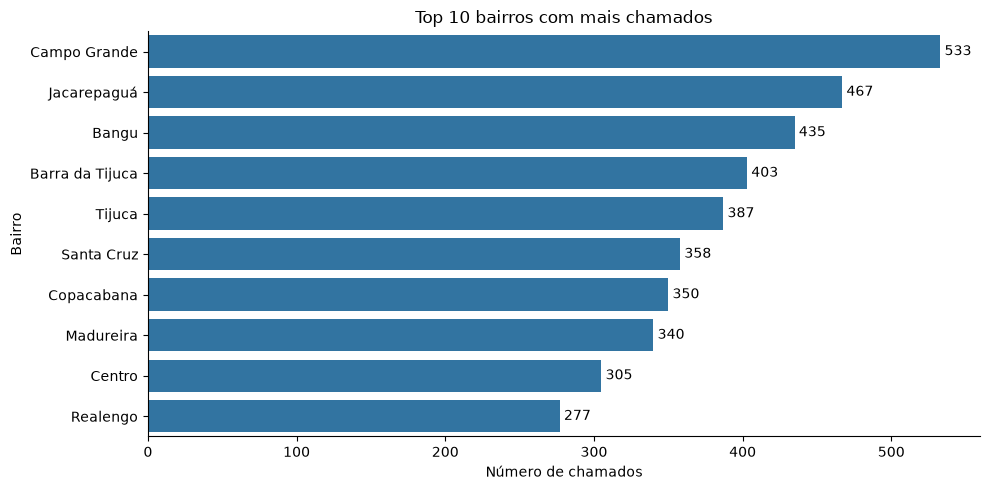

In [16]:
top_bairros = bairro_counts.head(10)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_bairros,
    y='bairro',
    x='chamados',
)


ax.bar_label(ax.containers[0], fmt='%d', padding=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Top 10 bairros com mais chamados')
plt.xlabel('Número de chamados')
plt.ylabel('Bairro')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top10_bairros_chamados.png', dpi=150)
plt.show()

In [17]:
top_bairros_lista = bairro_counts.head(10)['bairro']

df_top_bairros = df[df['bairro'].isin(top_bairros_lista)]

bairro_categoria = pd.crosstab(
    df_top_bairros['bairro'],
    df_top_bairros['categoria_real'].map(cat_map),
    normalize='index'
) * 100

bairro_categoria.round(1)

categoria_real,Barulho / Perturbação,Buraco em Via,Coleta de Lixo,Estacionamento Irregular,Iluminação Pública,Poda de Árvore,Sinalização,Vazamento de Esgoto
bairro,,,,,,,,
Bangu,7.4,19.1,15.2,8.3,23.2,9.2,5.1,12.6
Barra da Tijuca,8.7,16.9,17.9,6.7,23.1,8.7,4.2,13.9
Campo Grande,7.3,17.4,17.1,8.3,25.1,10.3,3.8,10.7
Centro,8.9,16.1,18.0,7.5,24.9,8.2,3.3,13.1
Copacabana,5.7,15.7,16.3,9.1,21.1,12.3,6.9,12.9
Jacarepaguá,8.4,18.6,16.1,9.6,22.9,7.3,3.4,13.7
Madureira,8.8,20.6,12.1,10.0,22.4,9.1,3.5,13.5
Realengo,8.7,18.8,15.9,7.9,20.6,7.2,5.8,15.2
Santa Cruz,8.7,18.2,15.6,10.3,22.6,9.5,3.6,11.5


- Os **6 bairros mais frequentes concentram 51,7%** dos chamados;

Como a mistura de categorias é parecida entre eles, não se espera que sejam os principais determinantes de erro. 

### 4. Padrões por Canal

In [18]:
canal_counts = df['canal'].value_counts()
canal_counts

canal
app_1746         2408
telefone_1746    1724
portal_web        868
Name: count, dtype: int64

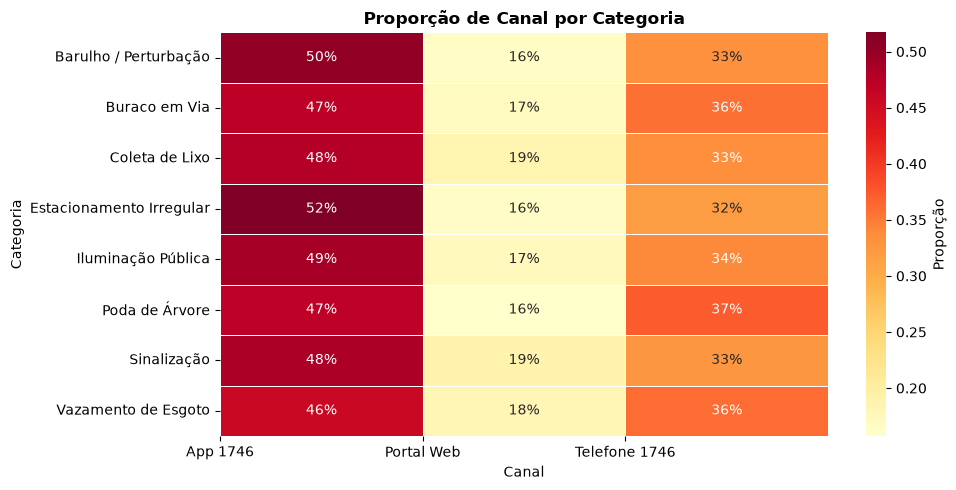

In [19]:
ct_abs = pd.crosstab(
    df['categoria_real'].map(cat_map),
    df['canal']
)
ct_norm = ct_abs.div(ct_abs.sum(axis=1), axis=0)

plt.figure(figsize=(10, 5))
sns.heatmap(ct_norm, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Proporção'})
plt.title('Proporção de Canal por Categoria', fontweight='bold')
plt.ylabel('Categoria')
plt.xlabel('Canal')
plt.xticks(ticks=range(3), labels=['App 1746', 'Portal Web', 'Telefone 1746'])
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'canal_categoria_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

- Canais: **app_1746 (48,2%)**, telefone_1746 (34,5%) e portal_web (17,4%);

Assim como os bairros a mistura de categorias é parecida entre eles, então também não se espera que sejam os principais determinantes de erro. 

### 5. Padrão Temporal

In [20]:
df['data_abertura'] = pd.to_datetime(df['data_abertura'])
df['mes_ano'] = df['data_abertura'].dt.to_period('M')
monthly = df.groupby('mes_ano').size()

print('Chamados por mês:')
print(monthly.to_string())
print(f'Média mensal: {monthly.mean():.0f} | Desvio Padrão: {monthly.std():.1f}')

Chamados por mês:
mes_ano
2026-01    855
2026-02    746
2026-03    862
2026-04    789
2026-05    875
2026-06    873
Freq: M
Média mensal: 833 | Desvio Padrão: 53.3


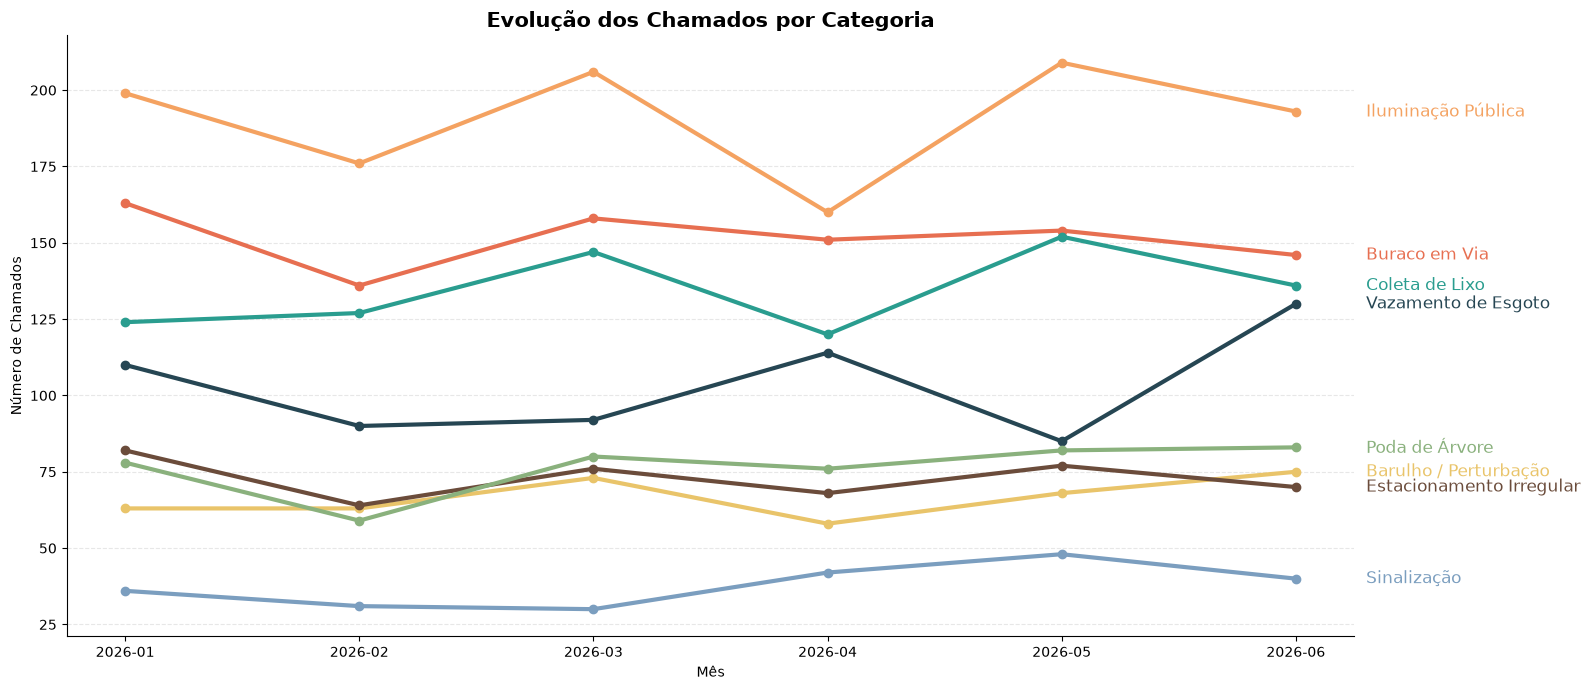

In [21]:
monthly_cat = (
    df.groupby(['mes_ano', 'categoria_real'])
      .size()
      .unstack(fill_value=0)
)
monthly_cat.index = monthly_cat.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 7))

for col in monthly_cat.columns:
    nome = cat_map.get(col, col)
    cor = cat_palette.get(col, "#666666")
    y = monthly_cat[col]

    ax.plot(monthly_cat.index, y, label=nome, color=cor, linewidth=3, marker="o", markersize=6)

    # Nome no final da linha
    ax.text(len(monthly_cat.index) - 0.70, y.iloc[-1], nome, color=cor, fontsize=12, va="center", ha="left")

ax.set_title(
    "Evolução dos Chamados por Categoria",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Mês")
ax.set_ylabel("Número de Chamados")
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "chamados_categoria_linhas.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

- Média de **~833 chamados/mês** (desvio padrão de 53,3), variando de 746 a 875;
- Sem tendência de crescimento ou queda e sem picos sazonais relevantes por categoria no período analisado.

A estabilidade temporal indica que a avaliação dos modelos não é distorcida por mudanças de distribuição ao longo do período (ausência de *drift* aparente). Que analisando para a realidade essa não é uma situação que queremos, em que no mundo ideal é que conforme o tempo passe a quantidade de chamados diminua. 

## Síntese

A base é limpa e estável, mas apresenta 3 caracterísitcas importantes que são: **desbalanceamento de classes**, **textos curtos e repetitivos** e **vocabulário rozoavelmente distintivo por categoria**. Esses três fatores nos dão uma direção na avaliação, e o que podemos esperar dos classificadores. Nas análises precisaremos métricas robustas ao desbalanceamento, e análises por categoria. Além disso atenção a possíveis confusões entre algumas classes específicas, porém que em geral apresente resultados positivos com a utilização de LLMs devido a distinção e especificidade de termos. 